In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("D:/Neurotrack Backend/backend/neurotrack-ml/data/uci_voice/parkinsons.data")

In [9]:
print("Shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))
print("\nColumn names:")
print(df.columns.tolist())
print("\nTarget distribution:")
print(df['status'].value_counts())
print("\nMissing values:")
print(df.isnull().sum().sum())

Shape: (195, 24)

First 3 rows:
             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   

   Shimmer:DDA      NHR     HNR  status      RPDE       DFA   spread1  \
0      0.06545  0.02211  21.033       1  0.414783  0.815285 -4.813031   
1      0.09403  0.01929  19.085       1  0.458359  0.819521 -4.075192   
2      0.08270  0.01309  20.651       1  0.429895  0.825288 -4.443179   

    spread2        D2       PPE  
0  0.266482  2.301442  0.284654

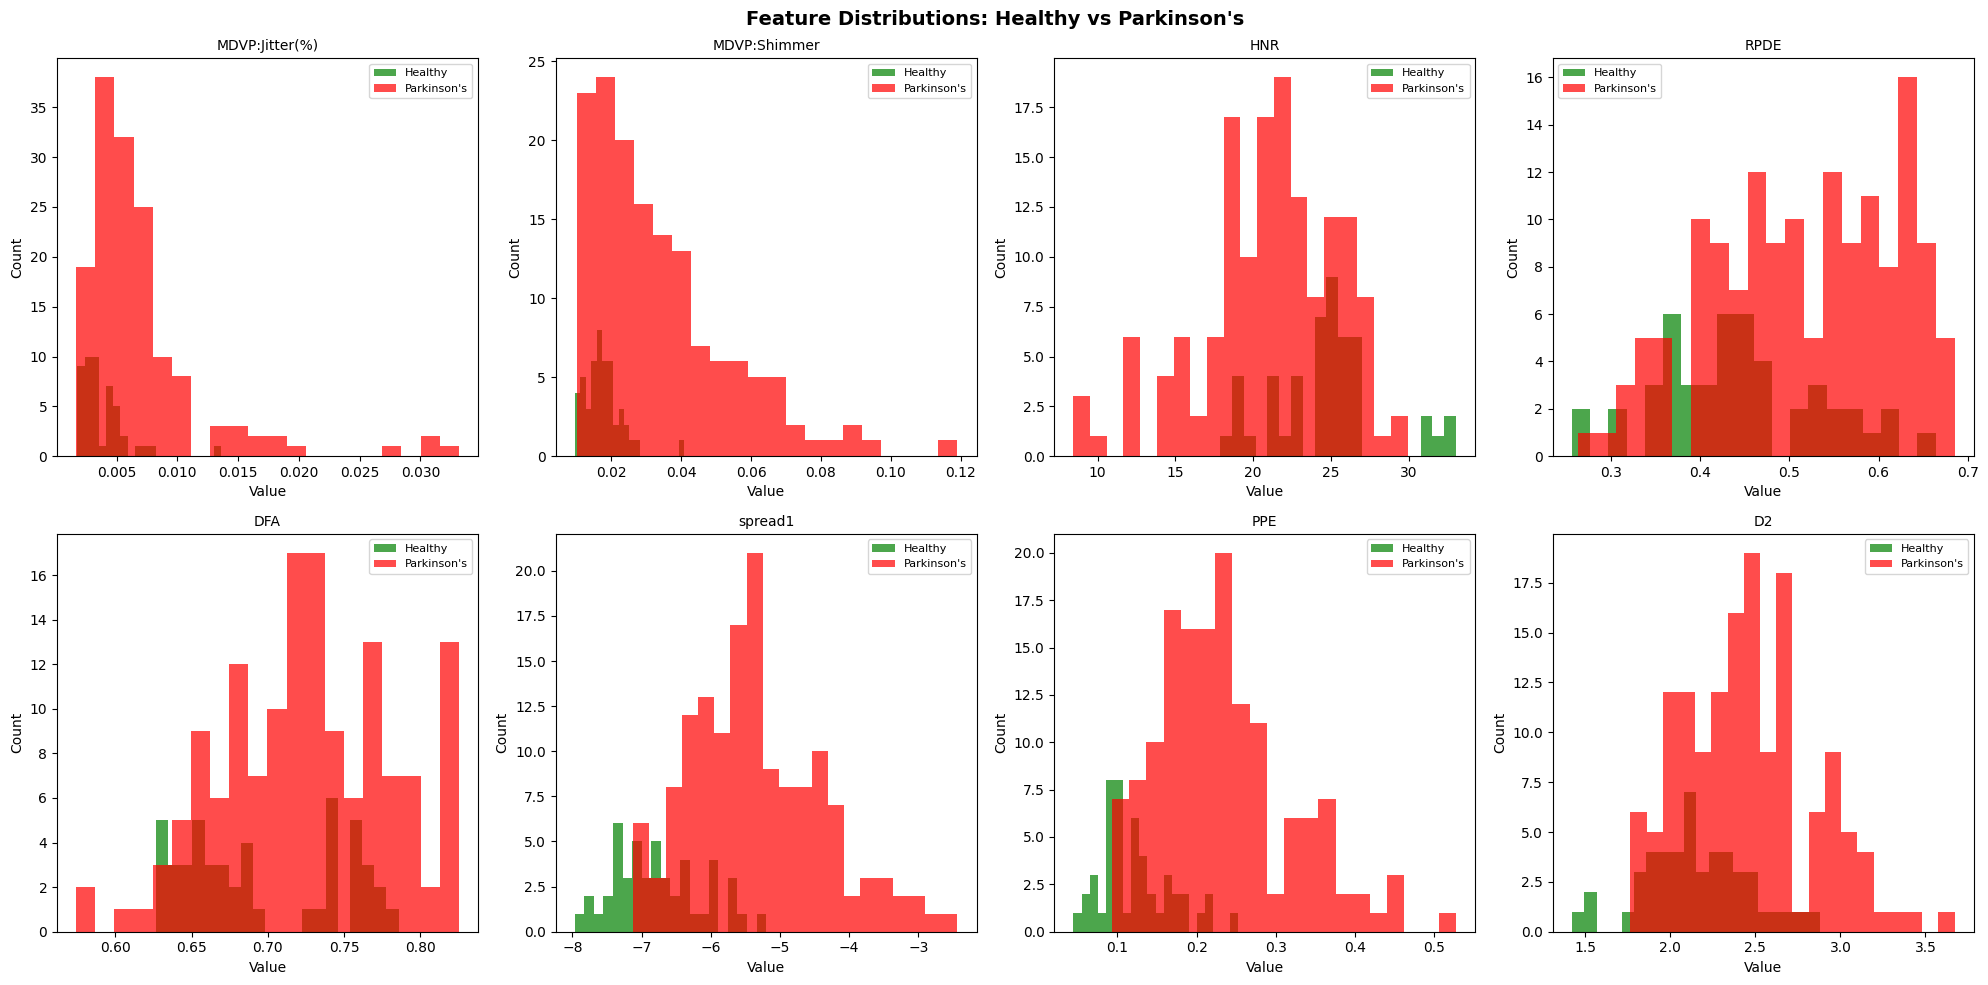

Plot saved


In [10]:
# ── VISUALISE CLASS DISTRIBUTION ───────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

key_features = [
    'MDVP:Jitter(%)',
    'MDVP:Shimmer',
    'HNR',
    'RPDE',
    'DFA',
    'spread1',
    'PPE',
    'D2'
]

for ax, feature in zip(axes.flat, key_features):
    # Plot healthy vs parkinsons distribution
    healthy = df[df['status']==0][feature]
    parkinsons = df[df['status']==1][feature]
    
    ax.hist(healthy, bins=20, alpha=0.7,
            color='green', label='Healthy')
    ax.hist(parkinsons, bins=20, alpha=0.7,
            color='red', label="Parkinson's")
    ax.set_title(feature, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions: Healthy vs Parkinson\'s',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/feature_distributions.png', dpi=150)
plt.show()
print("Plot saved")

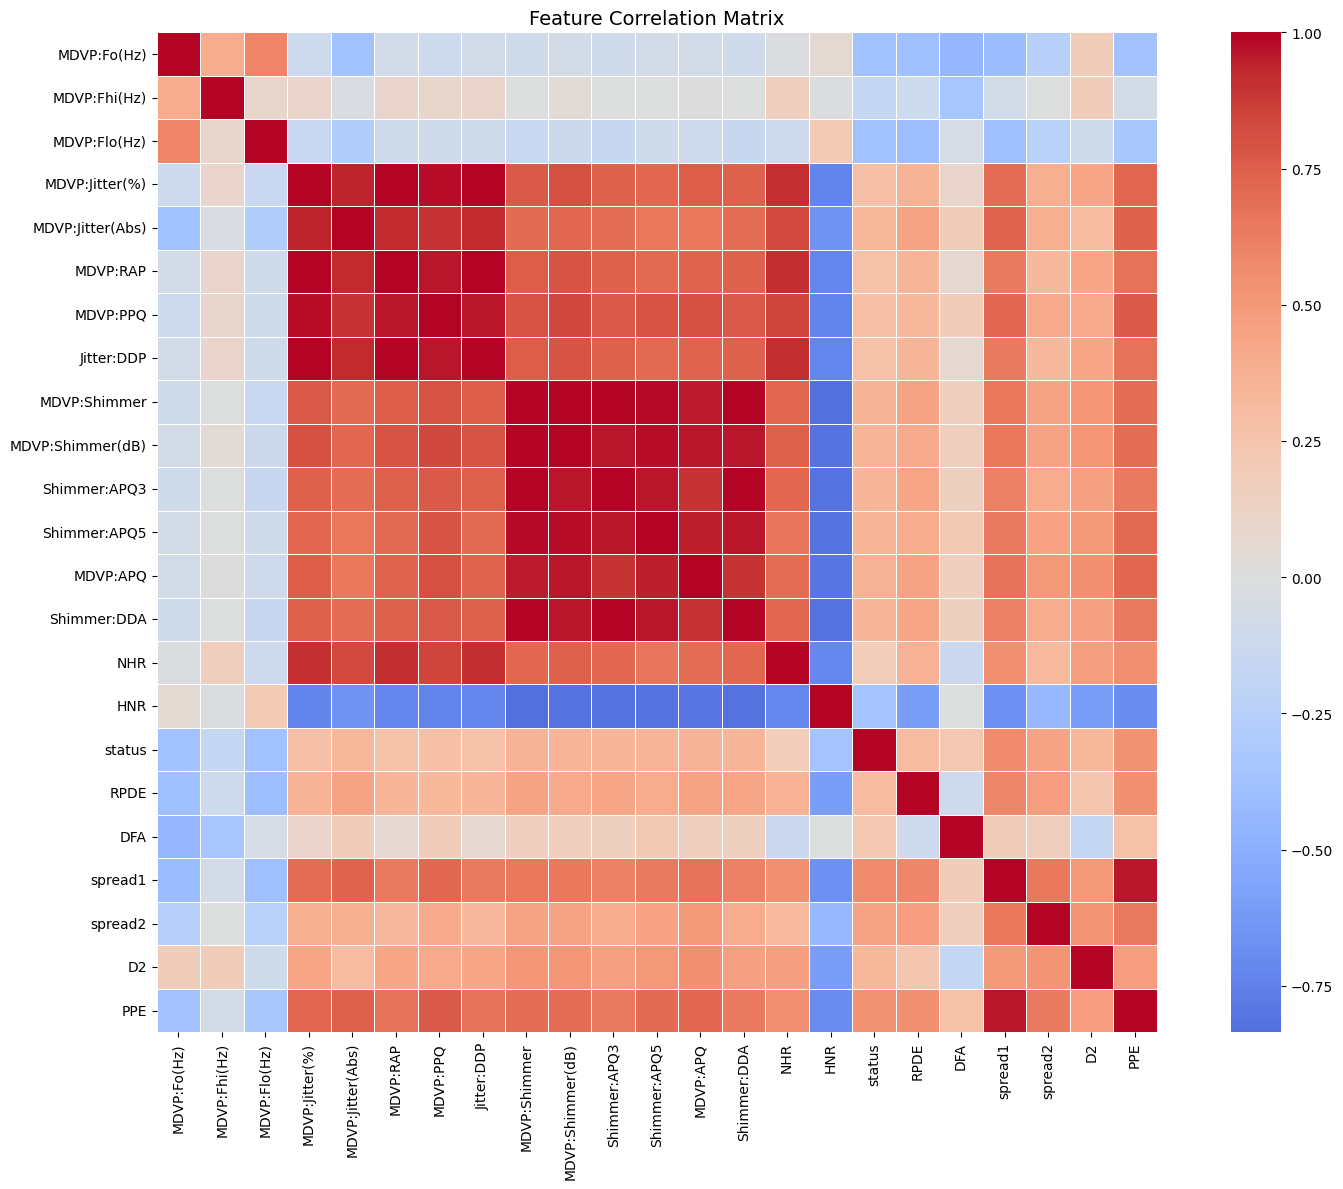


Top features correlated with status:
status          1.000000
spread1         0.564838
PPE             0.531039
spread2         0.454842
MDVP:Fo(Hz)     0.383535
MDVP:Flo(Hz)    0.380200
MDVP:Shimmer    0.367430
MDVP:APQ        0.364316
HNR             0.361515
Shimmer:APQ5    0.351148
Name: status, dtype: float64


In [11]:
# ── CORRELATION HEATMAP ────────────────────────────────────
plt.figure(figsize=(16, 12))

# Only numeric columns
numeric_df = df.drop(columns=['name'])

corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('../models/correlation_heatmap.png', dpi=150)
plt.show()

# Show which features correlate most with status
print("\nTop features correlated with status:")
status_corr = corr_matrix['status'].abs().sort_values(
    ascending=False)
print(status_corr.head(10))

In [12]:
# ── PREPARE DATA ───────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop name column — not a feature
df_clean = df.drop(columns=['name'])

# Separate features and target
X = df_clean.drop(columns=['status'])
y = df_clean['status']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature names:")
for i, col in enumerate(X.columns):
    print(f"  {i+1}. {col}")

# ── SPLIT DATA ─────────────────────────────────────────────
# 80% training, 20% testing
# stratify=y ensures both splits have same
# proportion of healthy vs parkinson's
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())

# ── SCALE FEATURES ─────────────────────────────────────────
# SVM needs scaled data — all features on same scale
scaler = StandardScaler()

# Fit ONLY on training data
# Transform both training and testing
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling done")
print("Mean of first feature after scaling:",
      round(X_train_scaled[:, 0].mean(), 4))
# Should be very close to 0

Features shape: (195, 22)
Target shape: (195,)

Feature names:
  1. MDVP:Fo(Hz)
  2. MDVP:Fhi(Hz)
  3. MDVP:Flo(Hz)
  4. MDVP:Jitter(%)
  5. MDVP:Jitter(Abs)
  6. MDVP:RAP
  7. MDVP:PPQ
  8. Jitter:DDP
  9. MDVP:Shimmer
  10. MDVP:Shimmer(dB)
  11. Shimmer:APQ3
  12. Shimmer:APQ5
  13. MDVP:APQ
  14. Shimmer:DDA
  15. NHR
  16. HNR
  17. RPDE
  18. DFA
  19. spread1
  20. spread2
  21. D2
  22. PPE

Training set size: (156, 22)
Testing set size: (39, 22)

Training target distribution:
status
1    118
0     38
Name: count, dtype: int64

Testing target distribution:
status
1    29
0    10
Name: count, dtype: int64

Scaling done
Mean of first feature after scaling: -0.0


In [13]:
import pandas as pd

# Convert the scaled array back to a DataFrame just for viewing
X_train_view = pd.DataFrame(X_train_scaled, columns=X.columns)

print("--- SCALED DATA (First 5 Rows) ---")
print(X_train_view.head())

print("\n--- PROOF OF SCALING (Mean and Std Dev) ---")
# This should show Mean close to 0 and Std close to 1 for all features
print(X_train_view.describe().loc[['mean', 'std']].iloc[:, :5]) # Showing first 5 columns


--- SCALED DATA (First 5 Rows) ---
   MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  MDVP:Jitter(Abs)  \
0    -1.063446     -0.915763     -0.335805       -0.557366         -0.422169   
1     0.583421      0.121494     -0.930523        0.191568         -0.150364   
2    -1.070570     -0.757698     -0.205924       -0.293037         -0.150364   
3     2.087044      0.592575      2.664484       -0.668461         -0.965779   
4     1.229699      0.414163     -0.669370       -0.530550         -0.693974   

   MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  MDVP:Shimmer(dB)  ...  \
0 -0.545728 -0.533719   -0.545797     -0.807610         -0.781828  ...   
1  0.226685  0.207389    0.226591      0.849549          0.672259  ...   
2 -0.315250 -0.146321   -0.316365      0.515715          0.402627  ...   
3 -0.548843 -0.594355   -0.548912     -0.673476         -0.632568  ...   
4 -0.486551 -0.496664   -0.485584     -0.550853         -0.555530  ...   

   MDVP:APQ  Shimmer:DDA       NHR     

In [14]:
# ── TRAIN SVM ──────────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

print("Training SVM with Grid Search...")
print("This finds the best settings automatically")
print("Please wait...\n")

# Pipeline combines scaling + SVM
# Even though we scaled above, pipeline
# makes it cleaner for grid search
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        probability=True,  # needed for predict_proba
        kernel='rbf',      # radial basis function kernel
        random_state=42
    ))
])

# Grid search tries all combinations of C and gamma
# and picks the best one using 5-fold cross validation
param_grid = {
    'svm__C':     [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,               # 5 fold cross validation
    scoring='roc_auc',  # optimize for AUC score
    n_jobs=-1,          # use all CPU cores
    verbose=2           # show progress
)

grid_search.fit(X_train, y_train)

print("\n── Grid Search Complete ──")
print("Best parameters found:")
print(grid_search.best_params_)
print("Best cross-validation AUC:",
      round(grid_search.best_score_, 4))

best_model = grid_search.best_estimator_

Training SVM with Grid Search...
This finds the best settings automatically
Please wait...

Fitting 5 folds for each of 20 candidates, totalling 100 fits

── Grid Search Complete ──
Best parameters found:
{'svm__C': 100, 'svm__gamma': 'scale'}
Best cross-validation AUC: 0.9755


── Classification Report ──
              precision    recall  f1-score   support

     Healthy       0.80      0.80      0.80        10
 Parkinson's       0.93      0.93      0.93        29

    accuracy                           0.90        39
   macro avg       0.87      0.87      0.87        39
weighted avg       0.90      0.90      0.90        39

AUC Score: 0.9759
AUC Percentage: 97.59%

Confusion Matrix breakdown:
True Negative  (Healthy correctly identified): 8
False Positive (Healthy wrongly flagged): 2
False Negative (Parkinson's missed): 2
True Positive  (Parkinson's correctly found): 27

Sensitivity (catching Parkinson's): 93.1%
Specificity (catching healthy): 80.0%


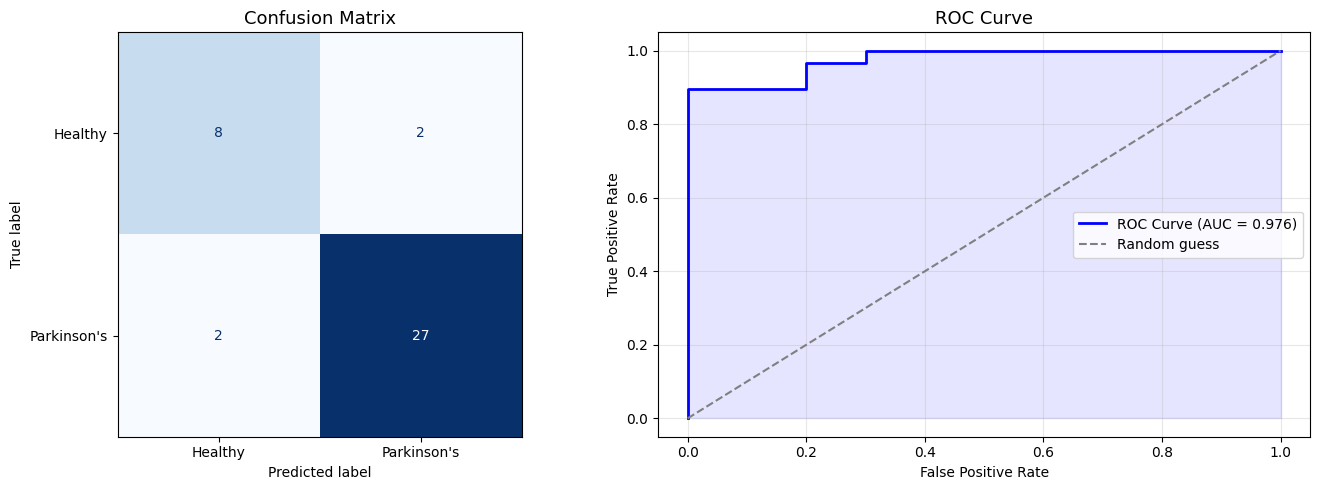

In [15]:
# ── EVALUATE ───────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    ConfusionMatrixDisplay
)

# Predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("── Classification Report ──")
print(classification_report(
    y_test, y_pred,
    target_names=['Healthy', "Parkinson's"]
))

auc = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {round(auc, 4)}")
print(f"AUC Percentage: {round(auc*100, 2)}%")

# ── CONFUSION MATRIX ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Healthy', "Parkinson's"]
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13)

# Add counts explanation
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix breakdown:")
print(f"True Negative  (Healthy correctly identified): {tn}")
print(f"False Positive (Healthy wrongly flagged): {fp}")
print(f"False Negative (Parkinson's missed): {fn}")
print(f"True Positive  (Parkinson's correctly found): {tp}")
print(f"\nSensitivity (catching Parkinson's): {round(tp/(tp+fn)*100,2)}%")
print(f"Specificity (catching healthy): {round(tn/(tn+fp)*100,2)}%")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='blue', lw=2,
             label=f'ROC Curve (AUC = {round(auc,3)})')
axes[1].plot([0,1], [0,1], color='gray',
             linestyle='--', label='Random guess')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='blue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/voice_model_evaluation.png', dpi=150)
plt.show()

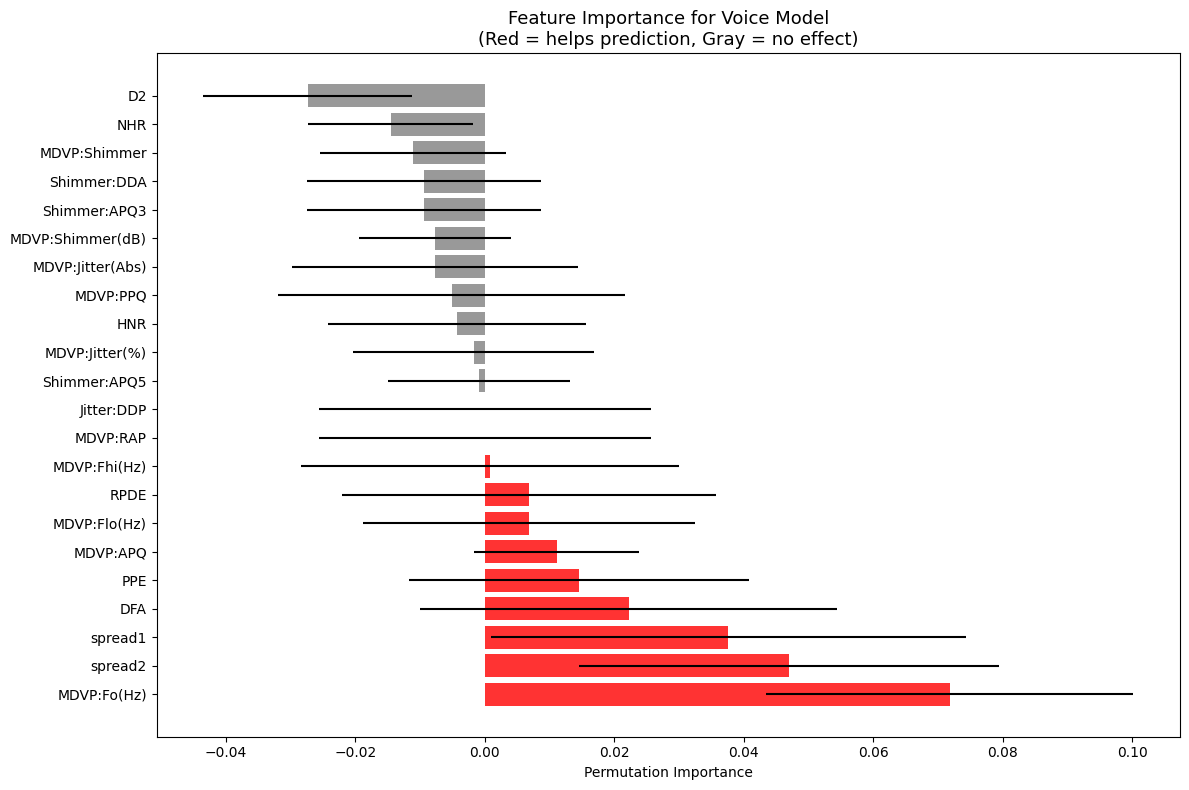


Top 5 most important features:
        feature  importance
0   MDVP:Fo(Hz)    0.071795
19      spread2    0.047009
18      spread1    0.037607
17          DFA    0.022222
21          PPE    0.014530


In [16]:
# ── FEATURE IMPORTANCE ─────────────────────────────────────
# SVM doesn't have direct feature importance
# Use permutation importance instead
from sklearn.inspection import permutation_importance

# Get the SVM from inside the pipeline
svm = best_model.named_steps['svm']
scaler_in_pipe = best_model.named_steps['scaler']

X_test_scaled_pipe = scaler_in_pipe.transform(X_test)

result = permutation_importance(
    svm,
    X_test_scaled_pipe,
    y_test,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
colors = ['red' if imp > 0 else 'gray'
          for imp in importance_df['importance']]
plt.barh(importance_df['feature'],
         importance_df['importance'],
         xerr=importance_df['std'],
         color=colors, alpha=0.8)
plt.xlabel('Permutation Importance')
plt.title('Feature Importance for Voice Model\n'
          '(Red = helps prediction, Gray = no effect)',
          fontsize=13)
plt.tight_layout()
plt.savefig('../models/voice_feature_importance.png',
            dpi=150)
plt.show()

print("\nTop 5 most important features:")
print(importance_df.head(5)[['feature','importance']])

In [19]:
# ── SAVE MODEL ─────────────────────────────────────────────
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Save the complete pipeline (scaler + SVM together)
joblib.dump(best_model, '../models/voice model/voice_model.pkl')

print("Model saved to ../models/voice model/voice_model.pkl")
print("File size:", 
      round(os.path.getsize('../models/voice model/voice_model.pkl')/1024, 2),
      "KB")

# Verify it loads correctly
loaded_model = joblib.load('../models/voice model/voice_model.pkl')
test_sample = X_test.iloc[0].values.reshape(1, -1)
test_prob = loaded_model.predict_proba(test_sample)[0][1]
test_pred = loaded_model.predict(test_sample)[0]

print("\nModel verification:")
print(f"Sample prediction probability: {round(test_prob*100,1)}%")
print(f"Prediction: {'Parkinson\'s' if test_pred==1 else 'Healthy'}")
print(f"Actual label: {'Parkinson\'s' if y_test.iloc[0]==1 else 'Healthy'}")

Model saved to ../models/voice model/voice_model.pkl
File size: 13.22 KB

Model verification:
Sample prediction probability: 13.5%
Prediction: Healthy
Actual label: Healthy


c:\Users\nihal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\nihal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [20]:
# ── SIMULATE WHAT YOUR APP WILL DO ─────────────────────────
print("=" * 50)
print("SIMULATING APP PREDICTION")
print("=" * 50)

# Pretend this is data coming from your Flutter app
# after LibROSA extracts features from user's voice
# (For now using UCI data as placeholder)
new_patient_features = {
    'MDVP:Fo(Hz)':       119.992,
    'MDVP:Fhi(Hz)':      157.302,
    'MDVP:Flo(Hz)':       74.997,
    'MDVP:Jitter(%)':      0.00784,
    'MDVP:Jitter(Abs)':    0.00007,
    'MDVP:RAP':            0.00370,
    'MDVP:PPQ':            0.00554,
    'Jitter:DDP':          0.01109,
    'MDVP:Shimmer':        0.04374,
    'MDVP:Shimmer(dB)':    0.42600,
    'Shimmer:APQ3':        0.02182,
    'Shimmer:APQ5':        0.03130,
    'MDVP:APQ':            0.02971,
    'Shimmer:DDA':         0.06545,
    'NHR':                 0.02211,
    'HNR':                21.03300,
    'RPDE':                0.41478,
    'DFA':                 0.81528,
    'spread1':            -4.81303,
    'spread2':             0.26648,
    'D2':                  2.30144,
    'PPE':                 0.28465
}

new_df = pd.DataFrame([new_patient_features])
probability = loaded_model.predict_proba(new_df)[0][1]
prediction = loaded_model.predict(new_df)[0]

print(f"\nVoice Risk Score: {round(probability*100, 1)}%")
print(f"Prediction: {'Parkinson\'s Disease Detected' if prediction==1 else 'Healthy'}")
print()

if probability > 0.7:
    print("Risk Level: HIGH — Recommend neurologist consultation")
elif probability > 0.4:
    print("Risk Level: MODERATE — Monitor and retest")
else:
    print("Risk Level: LOW — No significant indicators")

print()
print("Individual feature flags:")
print(f"  Jitter:  {new_patient_features['MDVP:Jitter(%)']*100:.3f}%",
      "⚠ HIGH" if new_patient_features['MDVP:Jitter(%)'] > 0.01 else "✓ Normal")
print(f"  Shimmer: {new_patient_features['MDVP:Shimmer']*100:.3f}%",
      "⚠ HIGH" if new_patient_features['MDVP:Shimmer'] > 0.03 else "✓ Normal")
print(f"  HNR:     {new_patient_features['HNR']:.3f} dB",
      "⚠ LOW" if new_patient_features['HNR'] < 20 else "✓ Normal")

SIMULATING APP PREDICTION

Voice Risk Score: 100.0%
Prediction: Parkinson's Disease Detected

Risk Level: HIGH — Recommend neurologist consultation

Individual feature flags:
  Jitter:  0.784% ✓ Normal
  Shimmer: 4.374% ⚠ HIGH
  HNR:     21.033 dB ✓ Normal
